## Optimización de precio (margen)

Con la curva de demanda ya estimada y validada, esta fase responde la pregunta final del proyecto, **¿qué precio conviene fijar?** No basta con saber cuánto  la demanda al cambio en el precio, hay que traducir esta relación en una decisión de negocio.

Para ello, se maximiza el **margen de contribución**, no el ingreso. La razón es económica, con una demanda tan elástica, maximizar el ingreso implica que se puede bajar el precio de forma constante, lo que nos llevaría a vender en pérdidas.

La demanda tiene forma de elasticidad constante:

$$Q(P) = A \cdot P^{\varepsilon}, \qquad \varepsilon = -4{,}62$$

y el margen a maximizar es:

$$\pi(P) = (P - c)\cdot Q(P)$$

De la condición de primer orden se obtiene la **regla del markup óptimo** (índice de Lerner):

$$P^{*} = c\cdot\frac{\varepsilon}{1+\varepsilon}, \qquad \frac{P^{*}-c}{P^{*}} = -\frac{1}{\varepsilon}$$

Se calcula primero el óptimo analítico con esta fórmula cerrada y después se verifica
numéricamente sobre la curva, comprobando que ambos coinciden. Todo el análisis se restringe
al rango de precios histórico: fuera de él la elasticidad no es fiable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Cargamos datos
df = pd.read_parquet('../data/processed/pepsi_2l_features.parquet')

print(df.shape)
print(df.columns.tolist())

(26663, 22)
['STORE', 'UPC', 'WEEK', 'MOVE', 'QTY', 'PRICE', 'SALE', 'PROFIT', 'DESCRIP', 'SIZE', 'COM_CODE', 'start', 'end', 'special', 'UNIT_PRICE', 'ln_q', 'ln_p', 'PROMO', 'FESTIVO', 'PRECIO_REF', 'DESCUENTO', 'PRECIO_REF_COCA']


In [3]:
# Coste: c = precio · (1 - PROFIT/100), mediana en semanas sin descuento
df["COSTE"] = df["UNIT_PRICE"] * (1 - df["PROFIT"] / 100)
regular = df[df["DESCUENTO"] < 0.01] # Filtramos semanas que solo tienen precio regular
C_REF = regular["COSTE"].median() # Obtenemos mediana de referencia

# Elasticidad 
EPSILON = -4.62

# Rango histórico de precios
P_MIN = df["UNIT_PRICE"].min()
P_MAX = df["UNIT_PRICE"].max()

print(f"Elasticidad: {EPSILON}")
print(f"Coste de referencia: {C_REF:.3f} ; (IQR [{regular['COSTE'].quantile(.25):.2f}, {regular['COSTE'].quantile(.75):.2f}], n={len(regular)})")
print(f"Rango de precios:  [{P_MIN:.2f}, {P_MAX:.2f}]")
# Comprobación: ¿suficientes semanas regulares y coste estable?
print(f"Filas a precio regular: {len(regular)} de {len(df)}")


Elasticidad: -4.62
Coste de referencia: 1.265 ; (IQR [1.15, 1.43], n=11430)
Rango de precios:  [0.68, 1.89]
Filas a precio regular: 11430 de 26663


Para realizar la optimización necesitamos la elasticidad, el coste unitario y el rango de precios.

Para la elasticidad seleccionamos la obtenida en la regresión log-log, el motivo es que el índice de Lerner asume que esta es constante, por tanto, emplear la elasticidad obtenida mediante ML rompería este supuesto. Esto no implica que la elasticidad obtenida con LightGBM no sea útil, de hecho ha servido para validar el resultado de log-log.

El coste unitario lo recuperamos de la variable `PROFIT`, que es el margen que tiene el minorista.

$$c = \text{UNIT\_PRICE}\cdot\left(1 - \frac{\text{PROFIT}}{100}\right)$$

El coste de referencia es la **mediana en las semanas a precio regular** (sin descuento). Se excluyen las semanas de promoción a propósito: en ellas el margen está comprimido y calcular el coste sobre esas filas lo distorsionaría. El coste de un producto no cambia porque esté de oferta; lo que cambia es el margen.

En cuanto al rango de precios, es necesario ya que la curva de demanda solo es fiable dentro de ese rango, por tanto el precio óptimo debe caer dentro del mismo. 

In [4]:
factor = EPSILON / (1 + EPSILON) # multiplicador sobre el coste
P_OPTIMO = C_REF * factor

margen_lerner = -1 / EPSILON # margen óptimo relativo a precio de venta

print(f"Factor de markup ε/(1+ε): {factor:.3f}") # cuántas veces el coste es el precio ópyimo
print(f"Precio óptimo P*: {P_OPTIMO:.3f} €") # precio recomendado
print(f"Margen de Lerner: {margen_lerner:.1%}") # 
print(f"¿Dentro del rango? {P_MIN <= P_OPTIMO <= P_MAX}")

Factor de markup ε/(1+ε): 1.276
Precio óptimo P*: 1.614 €
Margen de Lerner: 21.6%
¿Dentro del rango? True


El precio óptimo de contribución es **1,61 €**, con un markup del 27,6% sobre el coste (equivalente a un margen del 21,6% sobre el precio de venta). El valor cae dentro del rango histórico.

Es un resultado coherente con la práctica real: 1,61 € se sitúa justo entre los precios regulares que Dominick's aplicaba a Pepsi (1,59 y 1,69 €). El método no contradice la política de precios observada, sino que la respalda y le da fundamento cuantitativo: el precio regular de Pepsi estaba, de hecho, cerca del óptimo de margen. El valor añadido no es descubrir un precio inesperado, sino disponer de un criterio que justifica el precio y permite recalcularlo ante cambios en el coste o la elasticidad.

In [5]:
# Fijamos demanda media a precio regular y precio regular mediano
precio_reg_mediano = regular['UNIT_PRICE'].median()
demanda_reg_media = regular['MOVE'].mean()

A = demanda_reg_media / (precio_reg_mediano ** EPSILON)

# Creamos rejilla de precios dentro de rango de precios y curva de demanda
precios = np.linspace(P_MIN, P_MAX, 300) # generamos 300 valores
demanda = A * precios ** EPSILON
margen = (precios - C_REF) * demanda

# Nos aseguramos que el valor máximo del margen cae cerca del precio óptimo analítico
P_opt_numerico = precios[np.argmax(margen)]
print(f"P* analítico (fórmula): {P_OPTIMO:.3f}")
print(f"P* numérico (curva):    {P_opt_numerico:.3f}")

P* analítico (fórmula): 1.614
P* numérico (curva):    1.615


Para trabajar con la curva de margen completa —no solo con el óptimo puntual— se reconstruye la demanda con su forma de elasticidad constante, $Q = A\cdot P^{\varepsilon}$. La constante $A$ (la "altura" de la curva) se recupera anclándola a un punto real: la demanda media a precio regular, evaluada al precio regular mediano. Con la demanda reconstruida, el margen se calcula como $(P - c)\cdot Q(P)$ sobre una rejilla de precios dentro del rango histórico.

Como comprobación, el precio que maximiza numéricamente esta curva (1,615 €) coincide con el óptimo analítico de la fórmula de Lerner (1,614 €). Ambos caminos dan el mismo resultado, lo que confirma que la curva está bien construida.

Un único precio óptimo es poco realista como recomendación. En lugar de un valor exacto, se define una **banda de precios**, esta banda da a la empresa un margen de maniobra para promociones, redondeos o ajustes tácticos sin renunciar apenas a beneficio.

In [6]:
margen_max = margen.max()
umbral = 0.95 * margen_max
banda = precios[margen >= umbral]

banda_min, banda_max = banda.min(), banda.max()
print(f"Margen máximo en P* = {P_OPTIMO:.2f} €")
print(f"Banda (≥99% del margen máximo): [{banda_min:.2f} €, {banda_max:.2f} €]")

Margen máximo en P* = 1.61 €
Banda (≥99% del margen máximo): [1.51 €, 1.76 €]


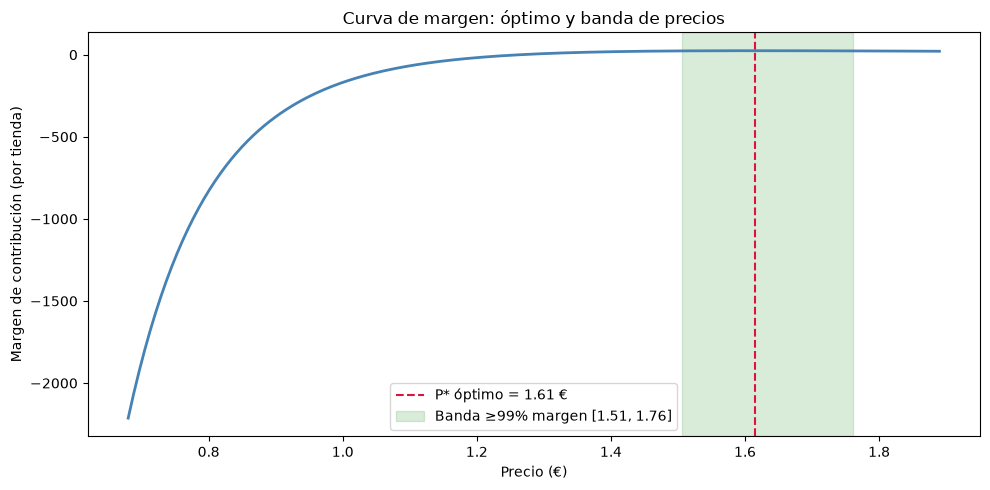

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(precios, margen, lw=2, color="steelblue")

# Marcar el óptimo
ax.axvline(P_OPTIMO, color="crimson", ls="--", lw=1.5, label=f"P* óptimo = {P_OPTIMO:.2f} €")
# Sombrear la banda
ax.axvspan(banda_min, banda_max, alpha=0.15, color="green",
           label=f"Banda ≥99% margen [{banda_min:.2f}, {banda_max:.2f}]")


ax.set(xlabel='Precio (€)', ylabel='Margen de contribución (por tienda)', title='Curva de margen: óptimo y banda de precios')

ax.legend()
plt.tight_layout()
plt.show()

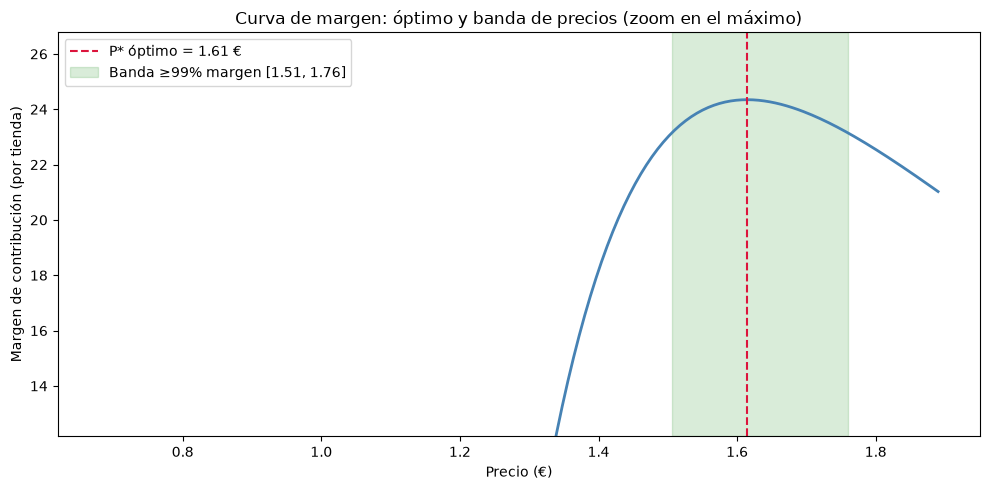

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(precios, margen, lw=2, color="steelblue")
ax.axvline(P_OPTIMO, color="crimson", ls="--", lw=1.5, label=f"P* óptimo = {P_OPTIMO:.2f} €")
ax.axvspan(banda_min, banda_max, alpha=0.15, color="green",
           label=f"Banda ≥99% margen [{banda_min:.2f}, {banda_max:.2f}]")

# Recortar el eje Y a la zona relevante (cerca del máximo)
ax.set_ylim(margen_max * 0.5, margen_max * 1.1)   # muestra solo la parte alta

ax.set(xlabel='Precio (€)', ylabel='Margen de contribución (por tienda)', title='Curva de margen: óptimo y banda de precios (zoom en el máximo)')

ax.legend()
plt.tight_layout()
plt.show()

La fórmula de Lerner da el precio óptimo como un punto, pero para visualizar el problema y extraer una recomendación con margen de maniobra conviene trabajar con la **curva de margen completa**, el beneficio de contribución en cada nivel de precio, no solo en el óptimo.

Se reconstruye la demanda con su forma de elasticidad constante, $Q = A\cdot P^{\varepsilon}$. La constante $A$ representa la altura de la curva y no interviene en el cálculo del precio óptimo, pero sí hace falta para dibujar la curva con magnitudes reales. Se recupera anclándola a un punto observado, la demanda media a precio regular, evaluada al precio regular mediano, de modo que la curva pase por un punto que realmente ocurrió en los datos:

$$A = \frac{Q_{\text{real}}}{P_{\text{real}}^{\;\varepsilon}}$$

Con la demanda reconstruida, el margen se calcula como $(P - c)\cdot Q(P)$ sobre una rejilla de precios dentro del rango histórico. El precio que maximiza numéricamente esta curva (1,615 €) coincide con el óptimo analítico de la fórmula (1,614 €), lo que confirma que la construcción es correcta.

Cómo un único precio óptimo es una recomendación frágil, cerca del máximo la curva de margen es plana, por lo que precios ligeramente distintos rinden prácticamente el mismo beneficio. En lugar de un valor exacto se define una banda, con un umbral del 95% la banda es [1,51 €, 1,76 €]; exigiendo el 99% se estrecha a [1,56 €, 1,67 €]. El umbral es una decisión: refleja cuánto margen se está dispuesto a sacrificar a cambio de flexibilidad de precio.

La banda resulta **asimétrica**, con más holgura al alza que a la baja. El motivo es económico: bajar el precio acerca al coste y comprime el margen unitario con rapidez, mientras que subirlo reduce la cantidad vendida de forma más gradual. En términos prácticos, equivocarse fijando un precio demasiado bajo penaliza más que hacerlo con uno demasiado alto.

A continuación, vamos a medir la sensibilidad del precio óptimo, es decir, modificando los supuestos (elasticidad y precio) que tanto se mueve el precio óptimo.

In [12]:
# Sensibilidad del precio óptimo a la elasticidad
elasticidades = {
    '-4.62 (log-log, controla Coca)': -4.62,
    '-4.24 (LightGBM)': -4.24,
    '-3.78 (log-log, sin Coca)':-3.78,
}

print('Elasticidad --> Precio óptimo')
for nombre, eps in elasticidades.items():
    p_opt = C_REF * eps / (1 + eps) # C
    print(f"  {nombre} --> P* = {p_opt:.3f} €")

Elasticidad --> Precio óptimo
  -4.62 (log-log, controla Coca) --> P* = 1.614 €
  -4.24 (LightGBM) --> P* = 1.655 €
  -3.78 (log-log, sin Coca) --> P* = 1.720 €


Con respecto a la sensibilidad a la elasticidad, el precio óptimo se mantiene estable, siendo la diferencia máxima de 11 cts. Esto nos lleva a que el precio es robusto en relación a la elasticidad, por tanto, no importa mucho cúal de las estimaciones obtenidas se use ya que todas llevan a un precio similar.

In [ ]:
# Sensibilidad del precio óptimo al coste
costes = {
    'bajo (Q1)': regular['COSTE'].quantile(0.25),
    'central (mediana)': C_REF, # C_REF ya es el valor de la mediana (cuantil 50)
    'alto (Q3)': regular['COSTE'].quantile(0.75),
}

print('Coste --> Precio óptimo (ε = -4.62)')
for nombre, c in costes.items():
    print(f'{nombre} c = {c:.3f} € --> P* = {c * factor:.3f} €')

Coste --> Precio óptimo (ε = -4.62)
bajo (Q1) c = 1.150 € --> P* = 1.468 €
central (mediana) c = 1.265 € --> P* = 1.614 €
alto (Q3) c = 1.430 € --> P* = 1.825 €


En cuanto a la sensibilidad del precio al coste, aquí la situación cambia totalmente, donde el precio si es sensible al coste. Esto resulta obvio si se observa la fórmula para calcular el precio $P^* = Coste * Factor$. Por tanto si el coste sube un 10%, el precio óptimo sube un 10% también.

En esta situación lo importante no es afinar la elasticidad, sino conocer de forma precisa los costes. Un error al determinar los costes se traduce en una variación de precio que puede provocar venta a pérdidas o venta a un precio muy elevado y por tanto una menor cantidad de unidades vendidas.
